In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.ticker as ticker
import pandas as pd

In [5]:
def tolabel(m):
    if m == 'DecisionTree':
        return 'DT'
    if m == 'LogisticRegression':
        return 'LR'
    if m == 'RandomForest':
        return 'RF'
    if m == 'AdaBoost':
        return 'AB'
    else:
        return m

def violinplot_sample(dataset, options, var_toplot, x_label, ylim):
    labels = []
    def add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        labels.append((mpatches.Patch(color=color), label))

    current = 0
    infinterval = -0.3
    leninterval = np.abs(infinterval) * 2
    plt.figure(figsize=(5, 4))
    ax = plt.gca()

    for _c in options:
        current += 1
        toplot = dataset[var_toplot+'_'+_c]
        #pos = np.arange(1, len(toplot) + 1, 1) + infinterval + leninterval * (current - 1) / (len(options) - 1)
        pos = [1 + infinterval + leninterval * (current - 1) / (len(options) - 1)]
        r = plt.violinplot(toplot,
                         positions = pos,
                         widths=0.15,
                         showmeans=True,
                         showextrema=True, showmedians=False,
                         bw_method='silverman')
        #r['cmedians'].set_color('w')
        #add_label(r, str(_c).split("/")[-1])
        add_label(r, tolabel(_c))

        # https://stackoverflow.com/questions/44253808/change-mean-indicator-in-violin-plot-to-a-circle on 24th May 2023
        # loop over the paths of the mean lines
        xy = [[l.vertices[:,0].mean(),l.vertices[0,1]] for l in r['cmeans'].get_paths()]
        xy = np.array(xy)
        ##alternatively get the means from the data
        #y = data.mean(axis=0)
        #x = np.arange(1,len(y)+1)
        #xy=np.c_[x,y]

        ax.scatter(xy[:,0], xy[:,1],s=5, c="k", marker="D", zorder=3)

        # make lines invisible
        r['cmeans'].set_visible(False)

        plt.boxplot(toplot,
        positions=pos,
                  widths=0.07,
                    showfliers = False,
                    boxprops = dict(linestyle=':', linewidth=1, c="k"),
                    whiskerprops = dict(linewidth=0),
                    medianprops = dict(linestyle=":", linewidth=1, c="k"),
                    showcaps = False,
                    notch= False)

    # Remove axis lines.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add labels to x axis.
    ax.set_xticks([1])
    ax.set_xticklabels([x_label])

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

    # Remove tick marks.
    ax.tick_params(
        bottom=False,
        left=False,
    )

    # Add bar lines as a horizontal grid.
    ax.yaxis.grid(color='grey', ls=':')
    plt.tight_layout()
    plt.ylim(ylim)

    # from https://stackoverflow.com/questions/54165569/can-i-turn-off-scientific-notation-in-matplotlib-bar-chart on 31 may 2023
    #def scientific(x, pos):
        # x:  tick value - ie. what you currently see in yticks
        # pos: a position - ie. the index of the tick (from 0 to 9 in this example)
    #    return '%.0E' % x

    #scientific_formatter = FuncFormatter(scientific)
    #ax.yaxis.set_major_formatter(scientific_formatter)

    #plt.legend(*zip(*labels), bbox_to_anchor=(1.1, 1.05))
    #plt.legend(*zip(*labels), frameon=True, facecolor="white", edgecolor="grey", framealpha=1.0)
    #plt.legend(*zip(*labels), bbox_to_anchor=(0.85, 1))

    #plt.savefig(x_label+".pdf", bbox_inches='tight')

In [6]:
def violinplot(dataset, options, var_label, var_toplot, x_label, ylim):
    labels = []
    def add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        labels.append((mpatches.Patch(color=color), label))

    current = 0
    infinterval = -0.3
    leninterval = np.abs(infinterval) * 2
    plt.figure(figsize=(5, 4))
    ax = plt.gca()

    for _c in options:
        current += 1
        toplot = dataset[dataset[var_label] == _c][var_toplot]
        #pos = np.arange(1, len(toplot) + 1, 1) + infinterval + leninterval * (current - 1) / (len(options) - 1)
        pos = [1 + infinterval + leninterval * (current - 1) / (len(options) - 1)]
        r = plt.violinplot(toplot,
                         positions = pos,
                         widths=0.15,
                         showmeans=True,
                         showextrema=True, showmedians=False,
                         bw_method='silverman')
        #r['cmedians'].set_color('w')
        #add_label(r, str(_c).split("/")[-1])
        add_label(r, tolabel(_c))

        # https://stackoverflow.com/questions/44253808/change-mean-indicator-in-violin-plot-to-a-circle on 24th May 2023
        # loop over the paths of the mean lines
        xy = [[l.vertices[:,0].mean(),l.vertices[0,1]] for l in r['cmeans'].get_paths()]
        xy = np.array(xy)
        ##alternatively get the means from the data
        #y = data.mean(axis=0)
        #x = np.arange(1,len(y)+1)
        #xy=np.c_[x,y]

        ax.scatter(xy[:,0], xy[:,1],s=5, c="k", marker="D", zorder=3)

        # make lines invisible
        r['cmeans'].set_visible(False)

        plt.boxplot(toplot,
        positions=pos,
                  widths=0.07,
                    showfliers = False,
                    boxprops = dict(linestyle=':', linewidth=1, c="k"),
                    whiskerprops = dict(linewidth=0),
                    medianprops = dict(linestyle=":", linewidth=1, c="k"),
                    showcaps = False,
                    notch= False)

    # Remove axis lines.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add labels to x axis.
    ax.set_xticks([1])
    ax.set_xticklabels([x_label])

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

    # Remove tick marks.
    ax.tick_params(
        bottom=False,
        left=False,
    )

    # Add bar lines as a horizontal grid.
    ax.yaxis.grid(color='grey', ls=':')
    plt.tight_layout()
    plt.ylim(ylim)

    # from https://stackoverflow.com/questions/54165569/can-i-turn-off-scientific-notation-in-matplotlib-bar-chart on 31 may 2023
    #def scientific(x, pos):
        # x:  tick value - ie. what you currently see in yticks
        # pos: a position - ie. the index of the tick (from 0 to 9 in this example)
    #    return '%.0E' % x

    #scientific_formatter = FuncFormatter(scientific)
    #ax.yaxis.set_major_formatter(scientific_formatter)

    #plt.legend(*zip(*labels), bbox_to_anchor=(1.1, 1.05))
    plt.legend(*zip(*labels), frameon=True, facecolor="white", edgecolor="grey", framealpha=1.0)
    #plt.legend(*zip(*labels), bbox_to_anchor=(0.85, 1))

    #plt.savefig(x_label+".pdf", bbox_inches='tight')

In [7]:
models = ['DecisionTree', 'LogisticRegression', 'KNN', 'RandomForest', 'AdaBoost', 'SVC']
datasets = ['pet', 'heart', 'weather', 'galaxy', 'character', 'consumer']
d_pet = pd.read_csv('../validation_pet/results/schedule/compiled_schedule_suggested.csv')
d_heart = pd.read_csv('../validation_heart/results/schedule/compiled_schedule_suggested.csv')
d_weather = pd.read_csv('../validation_weather/results/schedule/compiled_schedule_suggested.csv')
d_galaxy = pd.read_csv('../validation_galaxy/results/results_sample/compiled_schedule_suggested.csv')
d_character = pd.read_csv('../validation_character/results/schedule/compiled_schedule_suggested.csv')
d_consumer = pd.read_csv('../validation_consumer/results/schedule/compiled_schedule_suggested.csv')

galaxy_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

consumer_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

character_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

heart_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

pet_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

weather_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

d_pet['delta_Q_1'] = 0
d_heart['delta_Q_1'] = 0
d_weather['delta_Q_1'] = 0
d_galaxy['delta_Q_1'] = 0
d_consumer['delta_Q_1'] = 0
d_character['delta_Q_1'] = 0
d_pet['delta_Q_2'] = 0
d_heart['delta_Q_2'] = 0
d_weather['delta_Q_2'] = 0
d_galaxy['delta_Q_2'] = 0
d_consumer['delta_Q_2'] = 0
d_character['delta_Q_2'] = 0

for i in range(0, len(d_pet)):
    d_pet['delta_Q_1'].iloc[i] = d_pet.perf_1.values[i] / pet_original_perf[d_pet.algorithm.values[i]]
    d_pet['delta_Q_2'].iloc[i] = d_pet.perf_2.values[i] / pet_original_perf[d_pet.algorithm.values[i]]

for i in range(0, len(d_heart)):
    d_heart['delta_Q_1'].iloc[i] = d_heart.perf_1.values[i] / heart_original_perf[d_heart.algorithm.values[i]]
    d_heart['delta_Q_2'].iloc[i] = d_heart.perf_2.values[i] / heart_original_perf[d_heart.algorithm.values[i]]

for i in range(0, len(d_galaxy)):
    d_galaxy['delta_Q_1'].iloc[i] = d_galaxy.perf_1.values[i] / galaxy_original_perf[d_galaxy.algorithm.values[i]]
    d_galaxy['delta_Q_2'].iloc[i] = d_galaxy.perf_2.values[i] / galaxy_original_perf[d_galaxy.algorithm.values[i]]

for i in range(0, len(d_consumer)):
    d_consumer['delta_Q_1'].iloc[i] = d_consumer.perf_1.values[i] / consumer_original_perf[d_consumer.algorithm.values[i]]
    d_consumer['delta_Q_2'].iloc[i] = d_consumer.perf_2.values[i] / consumer_original_perf[d_consumer.algorithm.values[i]]

for i in range(0, len(d_character)):
    d_character['delta_Q_1'].iloc[i] = d_character.perf_1.values[i] / character_original_perf[d_character.algorithm.values[i]]
    d_character['delta_Q_2'].iloc[i] = d_character.perf_2.values[i] / character_original_perf[d_character.algorithm.values[i]]

for i in range(0, len(d_weather)):
    d_weather['delta_Q_1'].iloc[i] = d_weather.perf_1.values[i] / weather_original_perf[d_weather.algorithm.values[i]]
    d_weather['delta_Q_2'].iloc[i] = d_weather.perf_2.values[i] / weather_original_perf[d_weather.algorithm.values[i]]

d = pd.concat([d_pet, d_weather, d_character, d_consumer, d_galaxy, d_heart], ignore_index=True)

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


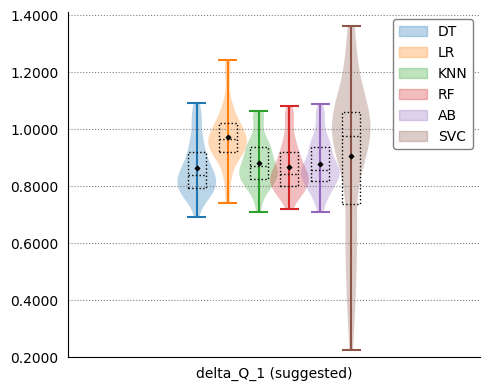

In [8]:
violinplot(d, models, 'algorithm', 'delta_Q_1', 'delta_Q_1 (suggested)', [0.2,1.41])

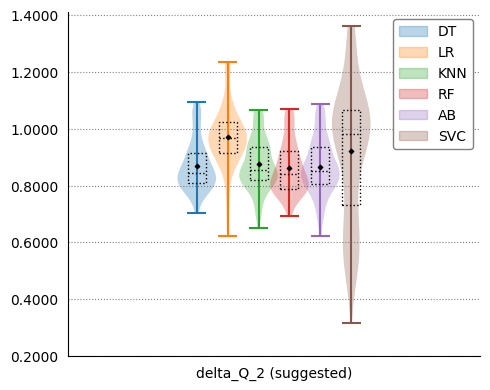

In [9]:
violinplot(d, models, 'algorithm', 'delta_Q_2', 'delta_Q_2 (suggested)', [0.2,1.41])


In [37]:
d_pet = pd.read_csv('../validation_pet/results/schedule/compiled_sample_schedule.csv')
d_heart = pd.read_csv('../validation_heart/results/schedule/compiled_sample_schedule.csv')
d_weather = pd.read_csv('../validation_weather/results/schedule/compiled_sample_schedule.csv')
d_galaxy = pd.read_csv('../validation_galaxy/results/results_sample/compiled_sample_schedule.csv')
d_character = pd.read_csv('../validation_character/results/schedule/compiled_sample_schedule.csv')
d_consumer = pd.read_csv('../validation_consumer/results/schedule/compiled_sample_schedule.csv')

galaxy_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

consumer_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

character_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

heart_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

pet_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

weather_original_perf = {
    'DecisionTree': 0.8489316598109451,
    'LogisticRegression': 0.7632625286934418,
    'KNN': 0.8596031818088326,
    'RandomForest': 0.8677511827887843,
    'AdaBoost': 0.8527756267575977,
    'SVC': 0.6896744361694442
}

In [38]:
for m in models:
    d_pet['delta_Q_1_'+m] = 0
    d_heart['delta_Q_1_'+m] = 0
    d_weather['delta_Q_1_'+m] = 0
    d_galaxy['delta_Q_1_'+m] = 0
    d_consumer['delta_Q_1_'+m] = 0
    d_character['delta_Q_1_'+m] = 0
    d_pet['delta_Q_2_'+m] = 0
    d_heart['delta_Q_2_'+m] = 0
    d_weather['delta_Q_2_'+m] = 0
    d_galaxy['delta_Q_2_'+m] = 0
    d_consumer['delta_Q_2_'+m] = 0
    d_character['delta_Q_2_'+m] = 0

In [39]:
for m in models:
    for i in range(0, len(d_pet)):
        d_pet['delta_Q_1_'+m].iloc[i] = d_pet[m+'_1'].values[i] / pet_original_perf[m]
        d_pet['delta_Q_2_'+m].iloc[i] = d_pet[m+'_2'].values[i] / pet_original_perf[m]

for m in models:
    for i in range(0, len(d_heart)):
        d_heart['delta_Q_1_'+m].iloc[i] = d_heart[m+'_1'].values[i] / heart_original_perf[m]
        d_heart['delta_Q_2_'+m].iloc[i] = d_heart[m+'_2'].values[i] / heart_original_perf[m]

for m in models:
    for i in range(0, len(d_galaxy)):
        d_galaxy['delta_Q_1_'+m].iloc[i] = d_galaxy[m+'_1'].values[i] / galaxy_original_perf[m]
        d_galaxy['delta_Q_2_'+m].iloc[i] = d_galaxy[m+'_2'].values[i] / galaxy_original_perf[m]

for m in models:
    for i in range(0, len(d_consumer)):
        d_consumer['delta_Q_1_'+m].iloc[i] = d_consumer[m+'_1'].values[i] / consumer_original_perf[m]
        d_consumer['delta_Q_2_'+m].iloc[i] = d_consumer[m+'_2'].values[i] / consumer_original_perf[m]

for m in models:
    for i in range(0, len(d_character)):
        d_character['delta_Q_1_'+m].iloc[i] = d_character[m+'_1'].values[i] / character_original_perf[m]
        d_character['delta_Q_2_'+m].iloc[i] = d_character[m+'_2'].values[i] / character_original_perf[m]

for m in models:
    for i in range(0, len(d_weather)):
        d_weather['delta_Q_1_'+m].iloc[i] = d_weather[m+'_1'].values[i] / pet_original_perf[m]
        d_weather['delta_Q_2_'+m].iloc[i] = d_weather[m+'_2'].values[i] / pet_original_perf[m]

d = pd.concat([d_pet, d_character, d_consumer, d_galaxy, d_heart, d_weather], ignore_index=True)


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


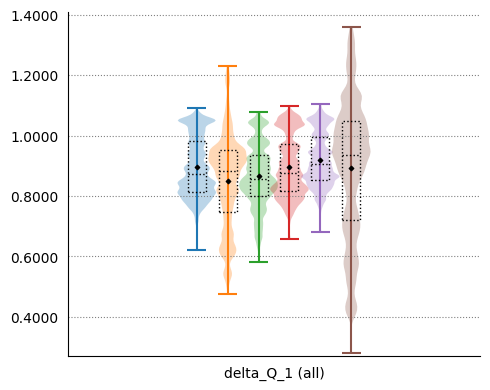

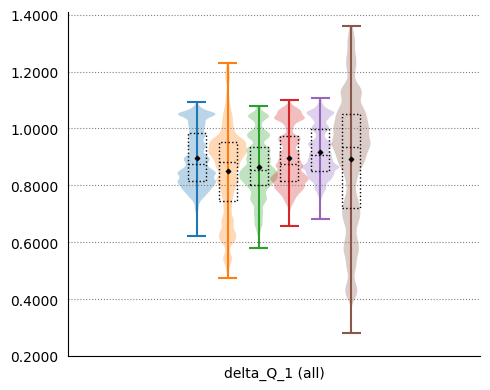

In [41]:
violinplot_sample(d, models, 'delta_Q_1', 'delta_Q_1 (all)', [0.2,1.41])

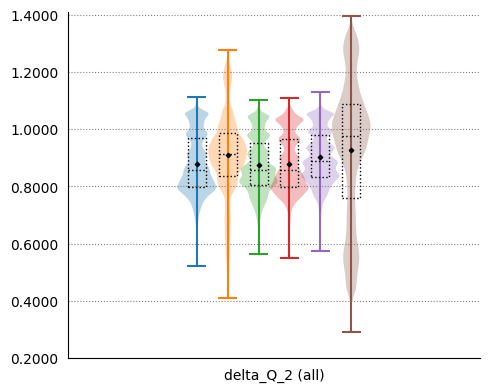

In [42]:
violinplot_sample(d, models, 'delta_Q_2', 'delta_Q_2 (all)', [0.2,1.41])
